In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [17]:
flights = sns.load_dataset('flights')
flights.groupby('year')['month'].count()

year
1949    12
1950    12
1951    12
1952    12
1953    12
1954    12
1955    12
1956    12
1957    12
1958    12
1959    12
1960    12
Name: month, dtype: int64

In [18]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [19]:
# year + month => datetime
flights['date'] = flights['year'].astype(str) + '-' + flights['month'].astype(str) + '-01'
flights = flights.sort_values(by='date').reset_index(drop=True)
flights


,year,month,passengers,date
0,1949,Apr,129,1949-Apr-01
1,1949,Aug,148,1949-Aug-01
2,1949,Dec,118,1949-Dec-01
3,1949,Feb,118,1949-Feb-01
4,1949,Jan,112,1949-Jan-01
...,...,...,...,...
139,1960,Mar,419,1960-Mar-01
140,1960,May,472,1960-May-01
141,1960,Nov,390,1960-Nov-01
142,1960,Oct,461,1960-Oct-01


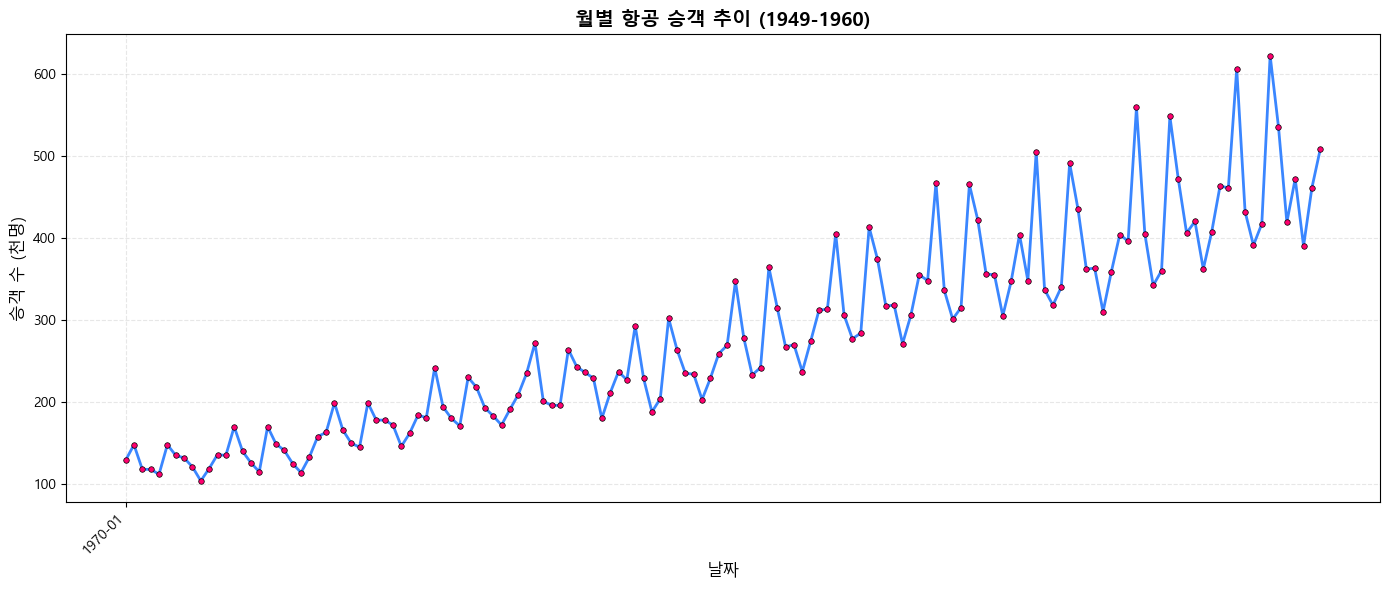

In [48]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(flights['date'], flights['passengers'], 
        linewidth=2, color='#3A86FF', marker='o', markersize=4,
        markerfacecolor='#FF006E', markeredgecolor='black', markeredgewidth=0.5)

ax.set_xlabel('날짜', fontsize=12)
ax.set_ylabel('승객 수 (천명)', fontsize=12)
ax.set_title('월별 항공 승객 추이 (1949-1960)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# X축 날짜 포맷팅
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 💡 인사이트: 명확한 상승 추세 + 주기적 변동 → 추세 + 계절성 패턴
# 💡 1950년대 항공 산업 성장기 반영 (12년간 약 4.5배 증가)

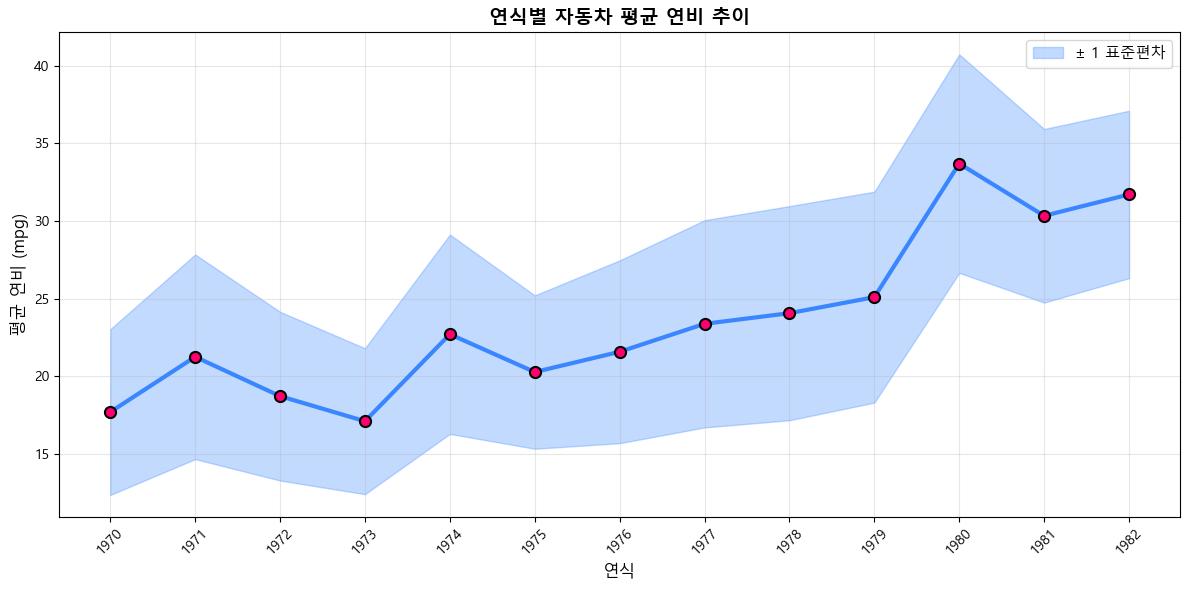


1970.0년 평균: 17.7 mpg
1982.0년 평균: 31.7 mpg
개선폭: 14.0 mpg (79.3% 향상)


In [49]:
# MPG 데이터 로드
mpg = sns.load_dataset('mpg')

# 연식별 평균 연비
mpg_by_year = mpg.groupby('model_year').agg({
    'mpg': ['mean', 'std', 'count']
}).reset_index()
mpg_by_year.columns = ['year', 'mean_mpg', 'std_mpg', 'count']

# 전체 연도 표시 (19XX)
mpg_by_year['full_year'] = 1900 + mpg_by_year['year']

fig, ax = plt.subplots(figsize=(12, 6))

# 평균 연비 라인
ax.plot(mpg_by_year['full_year'], mpg_by_year['mean_mpg'],
        marker='o', linewidth=3, markersize=8, color='#3A86FF',
        markerfacecolor='#FF006E', markeredgecolor='black', markeredgewidth=1.5)

# 표준편차 범위 (신뢰구간)
ax.fill_between(mpg_by_year['full_year'],
                mpg_by_year['mean_mpg'] - mpg_by_year['std_mpg'],
                mpg_by_year['mean_mpg'] + mpg_by_year['std_mpg'],
                alpha=0.3, color='#3A86FF', label='± 1 표준편차')

ax.set_xlabel('연식', fontsize=12)
ax.set_ylabel('평균 연비 (mpg)', fontsize=12)
ax.set_title('연식별 자동차 평균 연비 추이', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(mpg_by_year['full_year'])
ax.set_xticklabels(mpg_by_year['full_year'], rotation=45)

plt.tight_layout()
plt.show()

# 통계 분석
earliest = mpg_by_year.iloc[0]
latest = mpg_by_year.iloc[-1]
improvement = latest['mean_mpg'] - earliest['mean_mpg']
improvement_pct = (improvement / earliest['mean_mpg']) * 100

print(f"\n{earliest['full_year']}년 평균: {earliest['mean_mpg']:.1f} mpg")
print(f"{latest['full_year']}년 평균: {latest['mean_mpg']:.1f} mpg")
print(f"개선폭: {improvement:.1f} mpg ({improvement_pct:.1f}% 향상)")

# 💡 인사이트: 1973-1974년 급격한 연비 향상 → 1차 오일쇼크(1973) 직후
# 💡 12년간 연비 약 40% 개선 → 규제와 기술 발전의 결과
# 💡 표준편차 감소 추세 → 연비 품질이 균일해짐
